# Share Price Forecasting using Facebook Prophet

### 1. Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 2. Loading Dataset

In [2]:
!wget https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/26-Share%20Price%20Forecasting/Share-Price-Forecasting.csv

--2026-03-17 15:23:50--  https://media.githubusercontent.com/media/fatahrahimi330/100-Machine-Learning-Projects/refs/heads/master/26-Share%20Price%20Forecasting/Share-Price-Forecasting.csv
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 154077 (150K) [text/plain]
Saving to: ‘Share-Price-Forecasting.csv’

Share-Price-Forecas 100%[===================>] 150.47K   485KB/s    in 0.3s    

2026-03-17 15:23:51 (485 KB/s) - ‘Share-Price-Forecasting.csv’ saved [154077/154077]



In [3]:
df = pd.read_csv('Share-Price-Forecasting.csv')
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-01-27,15.315000,15.5120,15.131500,15.337500,15.337500,58406000
1,2015-01-28,15.490500,15.5755,15.190000,15.195500,15.195500,61276000
2,2015-01-29,15.236500,15.6400,14.966500,15.589000,15.589000,173132000
3,2015-01-30,17.316000,17.9750,17.037001,17.726500,17.726500,477122000
4,2015-02-02,17.502501,18.2500,17.500500,18.223499,18.223499,204638000


### 3. Data Preprocessing

1. Feature Engineering

In [4]:
df[['ds', 'y']] = df[['Date', 'Adj Close']]
df = df[['ds', 'y']]
df.head()

,ds,y
0,2015-01-27,15.337500
1,2015-01-28,15.195500
2,2015-01-29,15.589000
3,2015-01-30,17.726500
4,2015-02-02,18.223499


2. Train Test Split

In [5]:
split_date = '2019-07-21'
df_train = df.loc[df.ds <= split_date].copy()
df_test = df.loc[df.ds > split_date].copy()

### 4. Build and Fit the Model

In [6]:
import prophet as fbp
model = fbp.Prophet()
model.fit(df_train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


### 5. Make Prediction

In [13]:
predict = model.predict(df_test)
predict.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
1006,2023-07-20,108.893275,-122.672370,358.999788,-129.770084,351.537194,7.124708,7.124708,7.124708,1.287959,1.287959,1.287959,5.836749,5.836749,5.836749,0.0,0.0,0.0,116.017982
1007,2023-07-21,108.906229,-124.753025,359.561458,-129.988940,352.048182,7.006895,7.006895,7.006895,1.132720,1.132720,1.132720,5.874174,5.874174,5.874174,0.0,0.0,0.0,115.913124
1008,2023-07-24,108.945092,-124.064091,360.025724,-130.176913,352.599264,6.951290,6.951290,6.951290,1.053089,1.053089,1.053089,5.898201,5.898201,5.898201,0.0,0.0,0.0,115.896382
1009,2023-07-25,108.958047,-123.428786,359.160928,-130.390795,353.124082,7.161560,7.161560,7.161560,1.282641,1.282641,1.282641,5.878919,5.878919,5.878919,0.0,0.0,0.0,116.119606
1010,2023-07-26,108.971001,-125.045476,360.254914,-130.604676,353.648833,7.144080,7.144080,7.144080,1.296338,1.296338,1.296338,5.847742,5.847742,5.847742,0.0,0.0,0.0,116.115081


### 6. Evaluating the Model

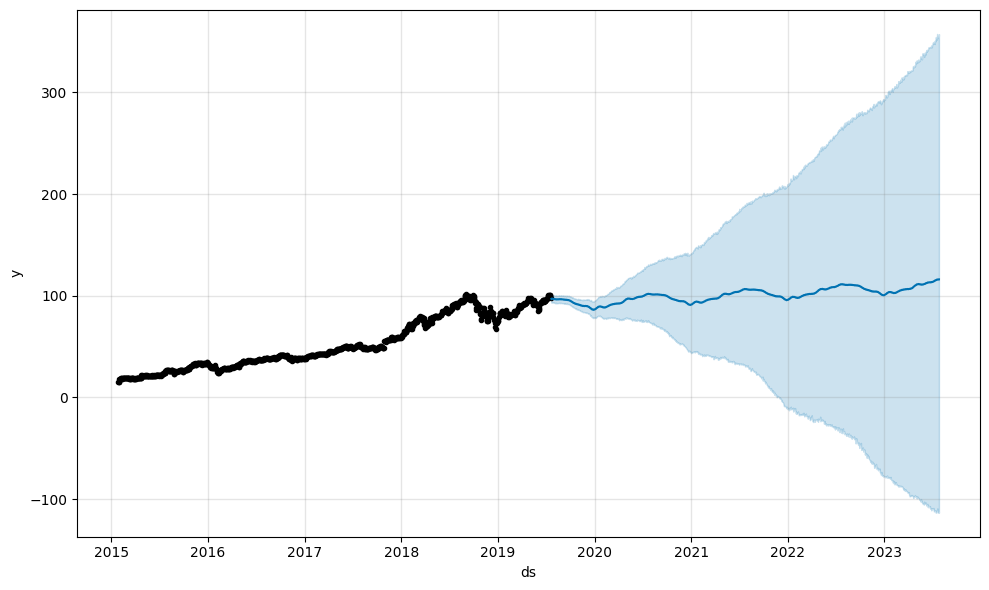

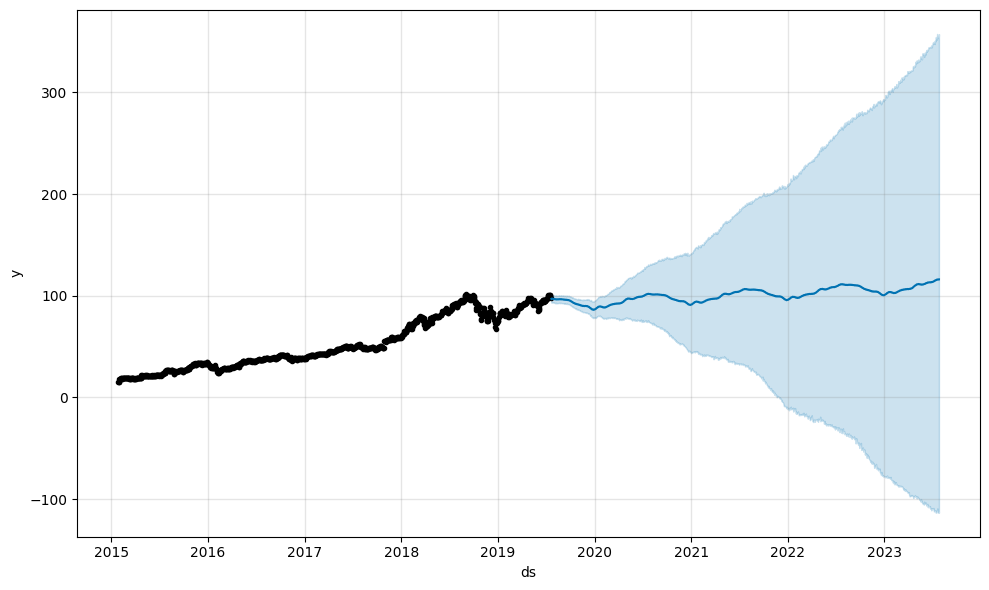

In [8]:
model.plot(predict)

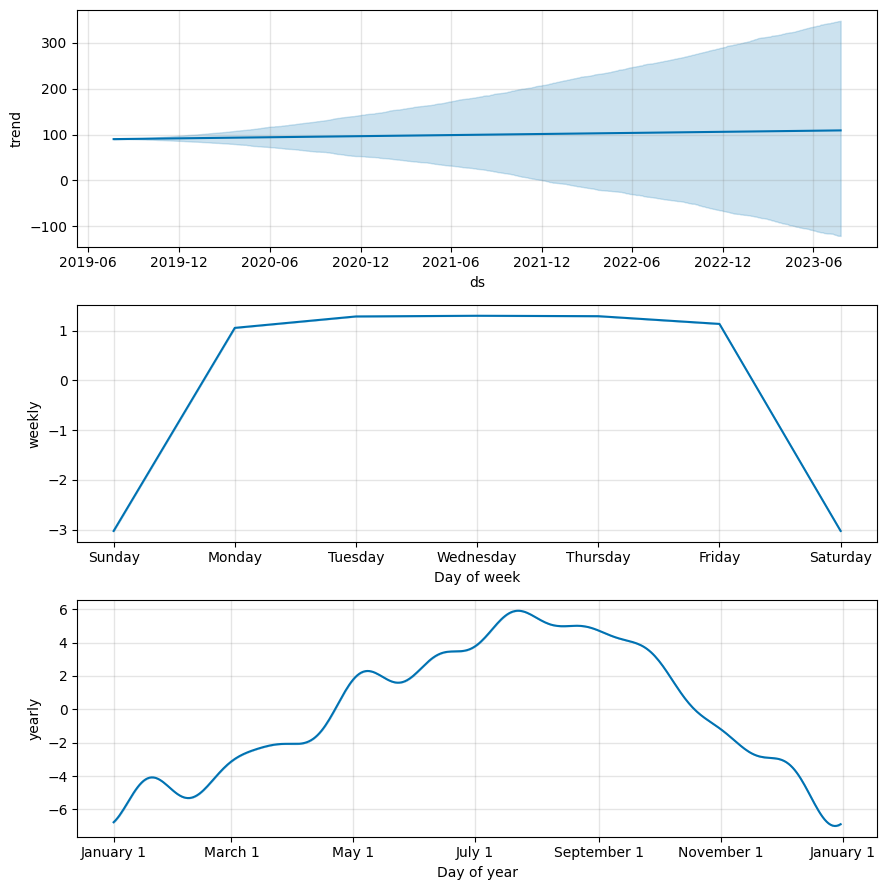

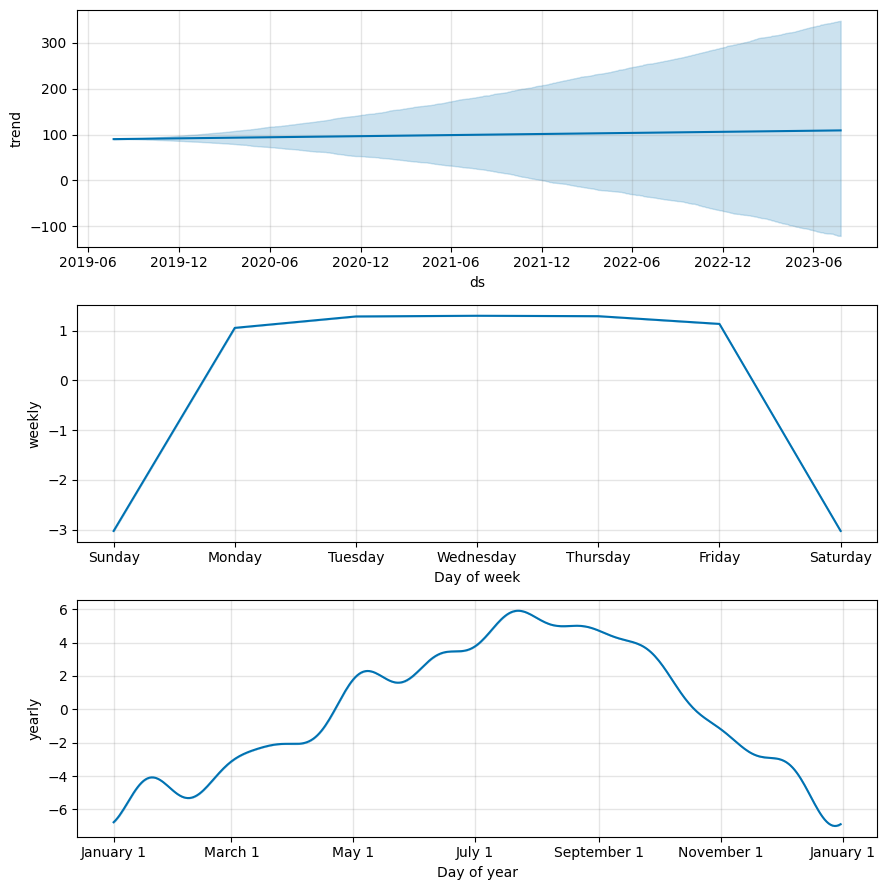

In [9]:
model.plot_components(predict)

In [10]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Mean Squared Error (MSE):", mean_squared_error(y_true = df_test["y"], y_pred = predict['yhat']))
print("Mean Absolute Error (MAE):", mean_absolute_error(y_true = df_test["y"], y_pred = predict['yhat']))

Mean Squared Error (MSE): 1928.6083835142474
Mean Absolute Error (MAE): 34.278188985030724


In [12]:
def mean_abs_perc_err(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("Mean Absolute % Error (MAPE): ", mean_abs_perc_err(y_true = np.asarray(df_test["y"]), y_pred = np.asarray(predict['yhat'])))

Mean Absolute % Error (MAPE):  22.615776795053907
